# **Travel Planner**

## 1. **Introduction**

ระบบช่วยวางแผนการเดินทางตามจำนวนวันและระยะทาง โดยมีเป้าหมายให้ผู้ใช้สามารถเที่ยวได้มากที่สุดในจำนวนวันที่กำหนด เมื่อการเที่ยว 1 วันคือการเที่ยว 1 จังหวัด โดยที่นับการเดินทางข้ามจังหวัดถูกนับรวมอยู่ในการเที่ยว 1 วันนั้นด้วย ระบบนี้จะประมวลผลจากข้อมูลสถานที่ที่ได้รับมาและสร้างเส้นทางที่มีประสิทธิภาพ

# **Dataset**
โค้ดนี้ใช้ dataset เฉพาะจังหวัดในภาคเหนือเท่านั้น ทำให้ข้อมูลมีขนาดเล็ก เพื่อจำกัดการ simulation

In [1]:
# ลิสต์ระยะทางจริงของตัวเมืองทั้ง 2 จังหวัดที่ติดกัน
# ข้อมูลจาก Google Maps ระยะทางอาจคลาดเคลื่อนจากความเป็นจริง
# โดยยึดตามระยะทางที่ใช้เวลาน้อยที่สุดโดยเฉลี่ย(ระยะทางที่ถูกแนะนำโดย Google Maps)
locations = [
    {'ptp': {'เชียงใหม่', 'ลำพูน'}, 'distance': 35},
    {'ptp': {'เชียงใหม่', 'ลำปาง'}, 'distance': 159},
    {'ptp': {'เชียงใหม่', 'แม่ฮ่องสอน'}, 'distance': 240},
    {'ptp': {'เชียงใหม่', 'เชียงราย'}, 'distance': 176},
    {'ptp': {'ลำพูน', 'ลำปาง'}, 'distance': 147},
    {'ptp': {'ลำปาง', 'แพร่'}, 'distance': 185},
    {'ptp': {'ลำปาง', 'พะเยา'}, 'distance': 103},
    {'ptp': {'ลำปาง', 'สุโขทัย'}, 'distance': 287},
    {'ptp': {'แพร่', 'น่าน'}, 'distance': 103},
    {'ptp': {'แพร่', 'อุตรดิตถ์'}, 'distance': 91},
    {'ptp': {'น่าน', 'พะเยา'}, 'distance': 205},
    {'ptp': {'น่าน', 'อุตรดิตถ์'}, 'distance': 185},
    {'ptp': {'พะเยา', 'เชียงราย'}, 'distance': 91},
    {'ptp': {'อุตรดิตถ์', 'สุโขทัย'}, 'distance': 80},
    {'ptp': {'สุโขทัย', 'พิษณุโลก'}, 'distance': 116},
    {'ptp': {'พิษณุโลก', 'เพชรบูรณ์'}, 'distance': 144},
    {'ptp': {'แม่ฮ่องสอน', 'ตาก'}, 'distance': 390},
    {'ptp': {'ตาก', 'กำแพงเพชร'}, 'distance': 132},
    {'ptp': {'กำแพงเพชร', 'สุโขทัย'}, 'distance': 157},
]

In [2]:
# รวมทุกภาค
locations = [
    # N
    {'ptp': {'เชียงใหม่', 'ลำพูน'}, 'distance': 35},
    {'ptp': {'เชียงใหม่', 'ลำปาง'}, 'distance': 159},
    {'ptp': {'เชียงใหม่', 'แม่ฮ่องสอน'}, 'distance': 240},
    {'ptp': {'เชียงใหม่', 'เชียงราย'}, 'distance': 176},
    {'ptp': {'ลำพูน', 'ลำปาง'}, 'distance': 147},
    {'ptp': {'ลำปาง', 'แพร่'}, 'distance': 185},
    {'ptp': {'ลำปาง', 'พะเยา'}, 'distance': 103},
    {'ptp': {'ลำปาง', 'สุโขทัย'}, 'distance': 287},
    {'ptp': {'แพร่', 'น่าน'}, 'distance': 103},
    {'ptp': {'แพร่', 'อุตรดิตถ์'}, 'distance': 91},
    {'ptp': {'น่าน', 'พะเยา'}, 'distance': 205},
    {'ptp': {'น่าน', 'อุตรดิตถ์'}, 'distance': 185},
    {'ptp': {'พะเยา', 'เชียงราย'}, 'distance': 91},
    {'ptp': {'อุตรดิตถ์', 'สุโขทัย'}, 'distance': 80},
    {'ptp': {'สุโขทัย', 'พิษณุโลก'}, 'distance': 116},
    {'ptp': {'พิษณุโลก', 'เพชรบูรณ์'}, 'distance': 144},
    {'ptp': {'แม่ฮ่องสอน', 'ตาก'}, 'distance': 390},
    {'ptp': {'ตาก', 'กำแพงเพชร'}, 'distance': 132},
    {'ptp': {'กำแพงเพชร', 'สุโขทัย'}, 'distance': 157},
    # NE
    {'ptp': {'อุดรธานี', 'หนองบัวลำภู'}, 'distance': 51},
    {'ptp': {'อุดรธานี', 'หนองคาย'}, 'distance': 52},
    {'ptp': {'อุดรธานี', 'ขอนแก่น'}, 'distance': 121},
    {'ptp': {'อุดรธานี', 'เลย'}, 'distance': 141},
    {'ptp': {'อุดรธานี', 'กาฬสินธุ์'}, 'distance': 196},
    {'ptp': {'อุดรธานี', 'สกลนคร'}, 'distance': 159},
    {'ptp': {'หนองบัวลำภู', 'เลย'}, 'distance': 98},
    {'ptp': {'หนองบัวลำภู', 'ขอนแก่น'}, 'distance': 110},
    {'ptp': {'หนองบัวลำภู', 'กาฬสินธุ์'}, 'distance': 150},
    {'ptp': {'หนองคาย', 'บึงกาฬ'}, 'distance': 136},
    {'ptp': {'หนองคาย', 'สกลนคร'}, 'distance': 172},
    {'ptp': {'ขอนแก่น', 'กาฬสินธุ์'}, 'distance': 75},
    {'ptp': {'ขอนแก่น', 'มหาสารคาม'}, 'distance': 72},
    {'ptp': {'ขอนแก่น', 'ชัยภูมิ'}, 'distance': 182},
    {'ptp': {'เลย', 'หนองคาย'}, 'distance': 90},
    {'ptp': {'เลย', 'เพชรบูรณ์'}, 'distance': 150},
    {'ptp': {'กาฬสินธุ์', 'มหาสารคาม'}, 'distance': 82},
    {'ptp': {'กาฬสินธุ์', 'ร้อยเอ็ด'}, 'distance': 110},
    {'ptp': {'กาฬสินธุ์', 'สกลนคร'}, 'distance': 150},
    {'ptp': {'สกลนคร', 'นครพนม'}, 'distance': 93},
    {'ptp': {'สกลนคร', 'บึงกาฬ'}, 'distance': 160},
    {'ptp': {'นครพนม', 'มุกดาหาร'}, 'distance': 80},
    {'ptp': {'มุกดาหาร', 'ยโสธร'}, 'distance': 100},
    {'ptp': {'มุกดาหาร', 'ร้อยเอ็ด'}, 'distance': 120},
    {'ptp': {'ร้อยเอ็ด', 'มหาสารคาม'}, 'distance': 50},
    {'ptp': {'ร้อยเอ็ด', 'ยโสธร'}, 'distance': 70},
    {'ptp': {'มหาสารคาม', 'ขอนแก่น'}, 'distance': 72},
    {'ptp': {'มหาสารคาม', 'สุรินทร์'}, 'distance': 150},
    {'ptp': {'ยโสธร', 'อำนาจเจริญ'}, 'distance': 60},
    {'ptp': {'ยโสธร', 'ศรีสะเกษ'}, 'distance': 90},
    {'ptp': {'อำนาจเจริญ', 'อุบลราชธานี'}, 'distance': 75},
    {'ptp': {'ศรีสะเกษ', 'สุรินทร์'}, 'distance': 130},
    {'ptp': {'ศรีสะเกษ', 'อุบลราชธานี'}, 'distance': 100},
    {'ptp': {'สุรินทร์', 'บุรีรัมย์'}, 'distance': 50},
    {'ptp': {'บุรีรัมย์', 'นครราชสีมา'}, 'distance': 120},
    {'ptp': {'นครราชสีมา', 'ชัยภูมิ'}, 'distance': 120},
    {'ptp': {'นครราชสีมา', 'ขอนแก่น'}, 'distance': 200},
    {'ptp': {'ชัยภูมิ', 'เพชรบูรณ์'}, 'distance': 150},
    # E
    {'ptp': {'นครนายก', 'ปราจีนบุรี'}, 'distance': 43},
    {'ptp': {'นครนายก', 'ฉะเชิงเทรา'}, 'distance': 61},
    {'ptp': {'ปราจีนบุรี', 'สระแก้ว'}, 'distance': 71},
    {'ptp': {'ปราจีนบุรี', 'ฉะเชิงเทรา'}, 'distance': 50},
    {'ptp': {'ฉะเชิงเทรา', 'ชลบุรี'}, 'distance': 79},
    {'ptp': {'ฉะเชิงเทรา', 'สระแก้ว'}, 'distance': 98},
    {'ptp': {'ชลบุรี', 'ระยอง'}, 'distance': 90},
    {'ptp': {'ชลบุรี', 'จันทบุรี'}, 'distance': 178},
    {'ptp': {'ชลบุรี', 'ตราด'}, 'distance': 225},
    {'ptp': {'ระยอง', 'จันทบุรี'}, 'distance': 112},
    {'ptp': {'จันทบุรี', 'ตราด'}, 'distance': 71},
    {'ptp': {'สระแก้ว', 'จันทบุรี'}, 'distance': 153},
    # W
    {'ptp': {'กาญจนบุรี', 'ราชบุรี'}, 'distance': 84},
    {'ptp': {'กาญจนบุรี', 'สุพรรณบุรี'}, 'distance': 97},
    {'ptp': {'กาญจนบุรี', 'นครปฐม'}, 'distance': 107},
    {'ptp': {'กาญจนบุรี', 'ตาก'}, 'distance': 300},
    {'ptp': {'ราชบุรี', 'นครปฐม'}, 'distance': 55},
    {'ptp': {'ราชบุรี', 'สุพรรณบุรี'}, 'distance': 119},
    {'ptp': {'ราชบุรี', 'เพชรบุรี'}, 'distance': 110},
    {'ptp': {'เพชรบุรี', 'ประจวบคีรีขันธ์'}, 'distance': 138},
    {'ptp': {'ตาก', 'สุโขทัย'}, 'distance': 80},
    {'ptp': {'ตาก', 'กำแพงเพชร'}, 'distance': 140},
    {'ptp': {'ประจวบคีรีขันธ์', 'เพชรบุรี'}, 'distance': 138},
    # CENTRAL
    {'ptp': {'กรุงเทพมหานคร', 'นนทบุรี'}, 'distance': 20},
    {'ptp': {'กรุงเทพมหานคร', 'ปทุมธานี'}, 'distance': 30},
    {'ptp': {'กรุงเทพมหานคร', 'สมุทรปราการ'}, 'distance': 29},
    {'ptp': {'นนทบุรี', 'ปทุมธานี'}, 'distance': 18},
    {'ptp': {'นนทบุรี', 'พระนครศรีอยุธยา'}, 'distance': 57},
    {'ptp': {'ปทุมธานี', 'พระนครศรีอยุธยา'}, 'distance': 41},
    {'ptp': {'ปทุมธานี', 'นครนายก'}, 'distance': 82},
    {'ptp': {'พระนครศรีอยุธยา', 'สระบุรี'}, 'distance': 40},
    {'ptp': {'พระนครศรีอยุธยา', 'ลพบุรี'}, 'distance': 78},
    {'ptp': {'สระบุรี', 'ลพบุรี'}, 'distance': 27},
    {'ptp': {'สระบุรี', 'นครนายก'}, 'distance': 49},
    {'ptp': {'ลพบุรี', 'อ่างทอง'}, 'distance': 48},
    {'ptp': {'ลพบุรี', 'ชัยนาท'}, 'distance': 61},
    {'ptp': {'อ่างทอง', 'สิงห์บุรี'}, 'distance': 18},
    {'ptp': {'อ่างทอง', 'สุพรรณบุรี'}, 'distance': 42},
    {'ptp': {'สิงห์บุรี', 'ชัยนาท'}, 'distance': 24},
    {'ptp': {'สิงห์บุรี', 'สุพรรณบุรี'}, 'distance': 56},
    {'ptp': {'ชัยนาท', 'สุพรรณบุรี'}, 'distance': 82},
    {'ptp': {'ชัยนาท', 'นครสวรรค์'}, 'distance': 62},
    {'ptp': {'สุพรรณบุรี', 'นครปฐม'}, 'distance': 91},
    {'ptp': {'สุพรรณบุรี', 'กาญจนบุรี'}, 'distance': 97},
    {'ptp': {'นครปฐม', 'ราชบุรี'}, 'distance': 55},
    {'ptp': {'นครปฐม', 'สมุทรสาคร'}, 'distance': 37},
    {'ptp': {'นครปฐม', 'กาญจนบุรี'}, 'distance': 107},
    {'ptp': {'สมุทรสาคร', 'สมุทรสงคราม'}, 'distance': 34},
    {'ptp': {'สมุทรสงคราม', 'ราชบุรี'}, 'distance': 36},
    {'ptp': {'ราชบุรี', 'เพชรบุรี'}, 'distance': 110},
    # S
    {'ptp': {'ชุมพร', 'ระนอง'}, 'distance': 126},
    {'ptp': {'ชุมพร', 'สุราษฎร์ธานี'}, 'distance': 189},
    {'ptp': {'ระนอง', 'พังงา'}, 'distance': 213},
    {'ptp': {'สุราษฎร์ธานี', 'พังงา'}, 'distance': 220},
    {'ptp': {'สุราษฎร์ธานี', 'กระบี่'}, 'distance': 160},
    {'ptp': {'สุราษฎร์ธานี', 'นครศรีธรรมราช'}, 'distance': 130},
    {'ptp': {'นครศรีธรรมราช', 'กระบี่'}, 'distance': 185},
    {'ptp': {'นครศรีธรรมราช', 'พัทลุง'}, 'distance': 110},
    {'ptp': {'นครศรีธรรมราช', 'สงขลา'}, 'distance': 190},
    {'ptp': {'พังงา', 'ภูเก็ต'}, 'distance': 87},
    {'ptp': {'พังงา', 'กระบี่'}, 'distance': 86},
    {'ptp': {'กระบี่', 'ตรัง'}, 'distance': 131},
    {'ptp': {'ตรัง', 'นครศรีธรรมราช'}, 'distance': 125},
    {'ptp': {'ตรัง', 'พัทลุง'}, 'distance': 90},
    {'ptp': {'ตรัง', 'สตูล'}, 'distance': 135},
    {'ptp': {'พัทลุง', 'สงขลา'}, 'distance': 85},
    {'ptp': {'สงขลา', 'สตูล'}, 'distance': 102},
    {'ptp': {'สงขลา', 'ยะลา'}, 'distance': 108},
    {'ptp': {'สงขลา', 'ปัตตานี'}, 'distance': 105},
    {'ptp': {'ยะลา', 'ปัตตานี'}, 'distance': 35},
    {'ptp': {'ยะลา', 'นราธิวาส'}, 'distance': 135},
    {'ptp': {'ปัตตานี', 'นราธิวาส'}, 'distance': 90},
    # เพิ่มเติม
    {'ptp': {'ลำปาง', 'เชียงราย'}, 'distance': 178},  # มีพรมแดนติดกัน
    {'ptp': {'ลำปาง', 'แพร่'}, 'distance': 185},  # ระยะทางสั้นกว่าไปอุตรดิตถ์
    {'ptp': {'เลย', 'พิษณุโลก'}, 'distance': 224},  # เลยใต้ติดพิษณุโลก
    {'ptp': {'ชัยนาท', 'อุทัยธานี'}, 'distance': 100},  # ชัยนาทติดอุทัยธานี
    {'ptp': {'อุทัยธานี', 'นครสวรรค์'}, 'distance': 102},  # อุทัยธานี-นครสวรรค์
    {'ptp': {'ราชบุรี', 'สมุทรสงคราม'}, 'distance': 44},  # ราชบุรีติดสมุทรสงคราม
    {'ptp': {'ระนอง', 'ชุมพร'}, 'distance': 121},  # ระนอง-ชุมพร (ติดภาคใต้)
    {'ptp': {'อุทัยธานี', 'สุพรรณบุรี'}, 'distance': 127},
    {'ptp': {'พิจิตร', 'พิษณุโลก'}, 'distance': 102},
    {'ptp': {'พิจิตร', 'เพชรบูรณ์'}, 'distance': 114},
    {'ptp': {'พิจิตร', 'กำแพงเพชร'}, 'distance': 149},
    {'ptp': {'พิจิตร', 'นครสวรรค์'}, 'distance': 72},
]

## 2. **หลักการที่ใช้**

ระบบนี้ใช้ **A* Search Algorithm** เพื่อค้นหาเส้นทางที่เหมาะสมที่สุด (Optimal Path) โดยมีรายละเอียดดังนี้:

1. **State Space**: แต่ละสถานที่คือสถานะหนึ่งในปัญหา
2. **Initial State**: สถานที่เริ่มต้นของการเดินทาง
3. **Goal State**: สถานะที่ครบตามจำนวนวันหรือข้อจำกัด
4. **Actions**: การเดินทางจากสถานที่หนึ่งไปยังอีกที่หนึ่ง
5. **Transition Model**: การเปลี่ยนแปลงสถานะเมื่อเลือกสถานที่ถัดไป
6. **Path Cost**: ค่าระยะทางหรือวันที่ใช้ในการเดินทาง
7. **Heuristic Function**: ใช้ระยะทางตรงเป็นตัวประมาณค่าว่าเหลือระยะทางเท่าไรถึงเป้าหมาย

## 3. **เทคนิคที่ใช้**

* 1. **A* Search (A-Star Search)**

    ระบบนี้ใช้ A\* ในการค้นหาเส้นทางที่มีประสิทธิภาพมากขึ้น โดยใช้ฟังก์ชัน:

    f(n) = g(n) + h(n)

    - **g(n)** = ระยะทางที่เดินทางมาแล้ว
    - **h(n)** = ระยะทางตรงจากสถานที่ปัจจุบันไปยังเป้าหมาย (ใช้เป็น Heuristic)

    การใช้ A\* ทำให้ระบบสามารถหาเส้นทางที่ดีที่สุดได้เร็วขึ้นกว่าการใช้ BFS

* 2. **Constraint Handling**

    ระบบจะตรวจสอบข้อจำกัดต่างๆ เช่น จำนวนวันและระยะทางสูงสุดเพื่อให้แน่ใจว่าเส้นทางที่เลือกไม่เกินข้อกำหนด

## 4. **ขั้นตอนการทำงาน**

### **Input**:

* ข้อมูลจากผู้ใช้ (User Input):
  * จำนวนวัน
  * ระยะทางสูงสุด (กิโลเมตร)
  * สถานที่เป้าหมาย

* ข้อมูลสถานที่ (Data):
  * ชื่อสถานที่
  * ระยะทางระหว่างสถานที่ (กิโลเมตร)
  * ระยะทางตรงระหว่างสถานที่ (ใช้เป็น heuristic)

### **Output**:

* เส้นทางการเดินทางที่ดีที่สุด พร้อมระยะทางรวม โดยเรียงตามเส้นทางที่เหมาะสมที่สุด

ระบบจะเลือกเส้นทางโดยใช้ **A* Search Algorithm** เพื่อให้ได้ผลลัพธ์ที่คุ้มค่าที่สุดตามข้อกำหนดของผู้ใช้






---


# **BFS**

In [3]:
# import defaultdict, deque and heapq
from collections import defaultdict, deque
import heapq

In [4]:
def heuristic(loc, goal, straight_line_dist):
    return straight_line_dist.get((loc, goal), 0)  # ใช้ระยะทางตรงเป็น heuristic

def travel_planner_astar(edges, start, max_days, max_distance, goal):
    # สร้างกราฟจาก edges
    graph = defaultdict(list)
    straight_line_dist = {}

    for edge in edges:
        loc1, loc2 = tuple(edge['ptp'])
        distance = edge['distance']
        graph[loc1].append((loc2, distance))
        graph[loc2].append((loc1, distance))

        # เก็บระยะทางตรงระหว่างสถานที่ (ใช้เป็น heuristic)
        straight_line_dist[(loc1, loc2)] = edge.get('straight_distance', distance)
        straight_line_dist[(loc2, loc1)] = edge.get('straight_distastraight_line_distnce', distance)

    # ใช้ A* Search
    priority_queue = [(0 + heuristic(start, goal, straight_line_dist), 0, start, [start])]  # (f(n), g(n), ปัจจุบัน, เส้นทาง)
    best_paths = []

    while priority_queue:
        f, g, current, path = heapq.heappop(priority_queue)

        if len(path) - 1 > max_days or g > max_distance:
            continue  # ข้ามเส้นทางที่เกินข้อจำกัด

        if current == goal:
            best_paths.append((path, g))
            continue

        for neighbor, distance in graph[current]:
            if neighbor not in path:
                new_g = g + distance
                new_f = new_g + heuristic(neighbor, goal, straight_line_dist)
                heapq.heappush(priority_queue, (new_f, new_g, neighbor, path + [neighbor]))

    return sorted(best_paths, key=lambda x: x[1])


# **Display output**

# **Implementation**
นำมาแสดงเป็น Connected graph

In [15]:
# Import matplotlib and geopandas
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# !pip install geopandas descartes
import geopandas as gpd

In [6]:
# ดาวน์โหลด font ภาษาไทย
!wget -q https://staff.su.ac.th/Misweb/download/THSarabunNew.zip
!unzip -o THSarabunNew.zip

# เพิ่ม font
font_dirs = ['/content/']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    fm.fontManager.addfont(font_file)

Archive:  THSarabunNew.zip
  inflating: THSarabunNew Bold.ttf   
  inflating: THSarabunNew BoldItalic.ttf  
  inflating: THSarabunNew Italic.ttf  
  inflating: THSarabunNew.ttf        


In [7]:
# เลือก font ที่รองรับภาษาไทย
fm._load_fontmanager(try_read_cache=False)
mpl.rcParams['font.family'] = 'TH Sarabun New'

In [8]:
# ดาวน์โหลดไฟล์ข้อมูลของแผนที่ประเทศไทย
!wget https://data.opendevelopmentmekong.net/th/dataset/8f3fa1b8-cb5c-48c8-9fd7-d3c213ea23db/resource/1559cee4-fedc-4330-be9c-d8cf3dd75015/download/tha_admbnda_adm1_rtsd_20190221.zip
!unzip tha_admbnda_adm1_rtsd_20190221.zip

# อ่านไฟล์ .shp
thailand = gpd.read_file('tha_admbnda_adm1_rtsd_20190221.shp')


--2026-02-25 17:46:20--  https://data.opendevelopmentmekong.net/th/dataset/8f3fa1b8-cb5c-48c8-9fd7-d3c213ea23db/resource/1559cee4-fedc-4330-be9c-d8cf3dd75015/download/tha_admbnda_adm1_rtsd_20190221.zip
Resolving data.opendevelopmentmekong.net (data.opendevelopmentmekong.net)... 192.53.174.192
Connecting to data.opendevelopmentmekong.net (data.opendevelopmentmekong.net)|192.53.174.192|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25579410 (24M) [application/zip]
Saving to: ‘tha_admbnda_adm1_rtsd_20190221.zip’

tha_admbnda_adm1_rt 100%[===================>]  24.39M  8.02MB/s    in 3.0s    

2026-02-25 17:46:24 (8.02 MB/s) - ‘tha_admbnda_adm1_rtsd_20190221.zip’ saved [25579410/25579410]

Archive:  tha_admbnda_adm1_rtsd_20190221.zip
  inflating: tha_admbnda_adm1_rtsd_20190221.shx  
  inflating: __MACOSX/._tha_admbnda_adm1_rtsd_20190221.shx  
  inflating: tha_admbnda_adm1_rtsd_20190221.shp.xml  
  inflating: __MACOSX/._tha_admbnda_adm1_rtsd_20190221.shp.xml  
  i

In [9]:
# หาเฉพาะจังหวัดที่อยู่ภาคเหนือ
northern_provinces = ['เชียงใหม่', 'ลำพูน', 'ลำปาง', 'แม่ฮ่องสอน', 'เชียงราย',
                     'แพร่', 'น่าน', 'พะเยา', 'อุตรดิตถ์', 'สุโขทัย',
                     'พิษณุโลก', 'เพชรบูรณ์', 'ตาก', 'กำแพงเพชร']

northern_thailand = thailand[thailand['ADM1_TH'].isin(northern_provinces)]

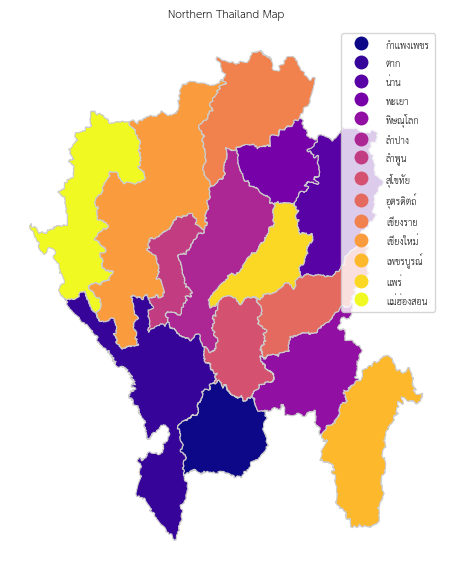

In [10]:
# สร้างแผนที่
mpl.rcParams['font.size'] = 10
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
northern_thailand.plot(column='ADM1_TH', cmap='plasma', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Northern Thailand Map')
ax.set_axis_off()

# แสดงแผนที่
plt.show()

In [11]:
all_provinces = [
    # ภาคเหนือ
    'เชียงใหม่', 'ลำพูน', 'ลำปาง', 'แม่ฮ่องสอน', 'เชียงราย',
    'แพร่', 'น่าน', 'พะเยา', 'อุตรดิตถ์', 'สุโขทัย',
    'พิษณุโลก', 'เพชรบูรณ์', 'ตาก', 'กำแพงเพชร', 'นครสวรรค์', 'อุทัยธานี',

    # ภาคตะวันออกเฉียงเหนือ
    'ขอนแก่น', 'กาฬสินธุ์', 'มหาสารคาม', 'ร้อยเอ็ด', 'อุดรธานี',
    'หนองบัวลำภู', 'เลย', 'หนองคาย', 'บึงกาฬ', 'สกลนคร', 'นครพนม',
    'มุกดาหาร', 'ยโสธร', 'อำนาจเจริญ', 'ศรีสะเกษ', 'สุรินทร์',
    'บุรีรัมย์', 'นครราชสีมา', 'ชัยภูมิ',

    # ภาคกลาง
    'กรุงเทพมหานคร', 'นนทบุรี', 'ปทุมธานี', 'พระนครศรีอยุธยา', 'สระบุรี',
    'ลพบุรี', 'ชัยนาท', 'อ่างทอง', 'สิงห์บุรี', 'สุพรรณบุรี', 'นครปฐม',
    'สมุทรปราการ', 'สมุทรสาคร', 'สมุทรสงคราม', 'กาญจนบุรี', 'ราชบุรี', 'พิจิตร',

    # ภาคตะวันออก
    'นครนายก', 'ปราจีนบุรี', 'ฉะเชิงเทรา', 'ชลบุรี', 'ระยอง',
    'จันทบุรี', 'ตราด', 'สระแก้ว',

    # ภาคตะวันตก
    'เพชรบุรี', 'ประจวบคีรีขันธ์',

    # ภาคใต้
    'ชุมพร', 'ระนอง', 'สุราษฎร์ธานี', 'นครศรีธรรมราช', 'พังงา', 'ภูเก็ต',
    'กระบี่', 'ตรัง', 'พัทลุง', 'สงขลา', 'สตูล', 'ยะลา', 'ปัตตานี', 'นราธิวาส'
]

all_thailand = thailand[thailand['ADM1_TH'].isin(all_provinces)]

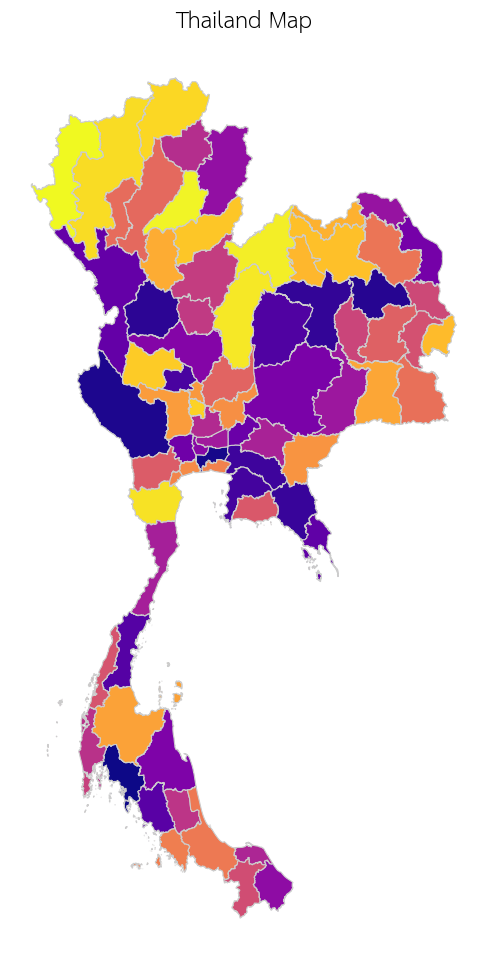

In [12]:
# ทั่วประเทศ
# สร้างแผนที่
mpl.rcParams['font.size'] = 20
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
all_thailand.plot(column='ADM1_TH', cmap='plasma', linewidth=0.8, ax=ax, edgecolor='0.8', legend=False)
ax.set_title('Thailand Map')
ax.set_axis_off()

# แสดงแผนที่
plt.show()

In [13]:
# จะพิมพ์เองหรือมีข้อมูลกำหนดตั้งต้น
manual = False

# กำหนดสถานที่เริ่มต้น
if (manual):
    print("ระบุชื่อจังหวัดเริ่มต้น")
    start_location = input()
    print("\nระบุจำนวนวันสูงสุด(ตอบเพียงตัวเลข)")
    max_day = int(input())
    print("\nระบุระยะทางสูงสุดในหน่วยกิโลเมตร(ตอบเพียงตัวเลข)")
    max_distance = float(input())
    print("ระบุชื่อจังหวัดสุดท้าย")
    end_location = input()
    print("\n")
#------------------------
else:
    start_location = "เชียงใหม่"
    max_day = 7
    max_distance = 1000000
    end_location = "ลำพูน"

# เรียกใช้งานฟังก์ชัน สถานที่, สถานที่เริ่มต้น, จำนวนวันที่เที่ยว, ระยะทางที่มากที่สุดที่จะเที่ยวได้
results = travel_planner_astar(locations, start_location, max_day, max_distance, end_location)

# Filter out duplicate paths
filtered_results = []
seen_paths = set()
for path, distance in results:
    # Convert the path to a tuple to make it hashable for the set
    path_tuple = tuple(path)
    if path_tuple not in seen_paths:
        seen_paths.add(path_tuple)
        filtered_results.append((path, distance))

# Now use filtered_results instead of results
if filtered_results:
    print("เริ่มเดินทางจากจังหวัด: " + start_location + \
          "\nจำนวนวันสูงสุด: " + str(int(max_day)) + \
          "\nจำนวนระยะทางสูงสุด(km): " + str(max_distance) + "\n")
    for i, (path, distance) in enumerate(filtered_results, 1):
        print(f"เส้นทางที่ {i}: {' > '.join(path)} (ระยะทางรวม: {distance} km)")

เริ่มเดินทางจากจังหวัด: เชียงใหม่
จำนวนวันสูงสุด: 7
จำนวนระยะทางสูงสุด(km): 1000000

เส้นทางที่ 1: เชียงใหม่ > ลำพูน (ระยะทางรวม: 35 km)
เส้นทางที่ 2: เชียงใหม่ > ลำปาง > ลำพูน (ระยะทางรวม: 306 km)
เส้นทางที่ 3: เชียงใหม่ > เชียงราย > ลำปาง > ลำพูน (ระยะทางรวม: 501 km)
เส้นทางที่ 4: เชียงใหม่ > เชียงราย > พะเยา > ลำปาง > ลำพูน (ระยะทางรวม: 517 km)
เส้นทางที่ 5: เชียงใหม่ > เชียงราย > พะเยา > น่าน > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 907 km)
เส้นทางที่ 6: เชียงใหม่ > เชียงราย > พะเยา > น่าน > อุตรดิตถ์ > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 1080 km)
เส้นทางที่ 7: เชียงใหม่ > แม่ฮ่องสอน > ตาก > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1144 km)
เส้นทางที่ 8: เชียงใหม่ > เชียงราย > พะเยา > น่าน > อุตรดิตถ์ > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1171 km)
เส้นทางที่ 9: เชียงใหม่ > แม่ฮ่องสอน > ตาก > สุโขทัย > อุตรดิตถ์ > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 1213 km)
เส้นทางที่ 10: เชียงใหม่ > แม่ฮ่องสอน > ตาก > กำแพงเพชร > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1353 km)


เริ่มเดินทางจากจังหวัด: เชียงใหม่
จำนวนวันสูงสุด: 7
จำนวนระยะทางสูงสุด(km): 1000000

เส้นทางที่ 1: เชียงใหม่ > ลำพูน (ระยะทางรวม: 35 km)


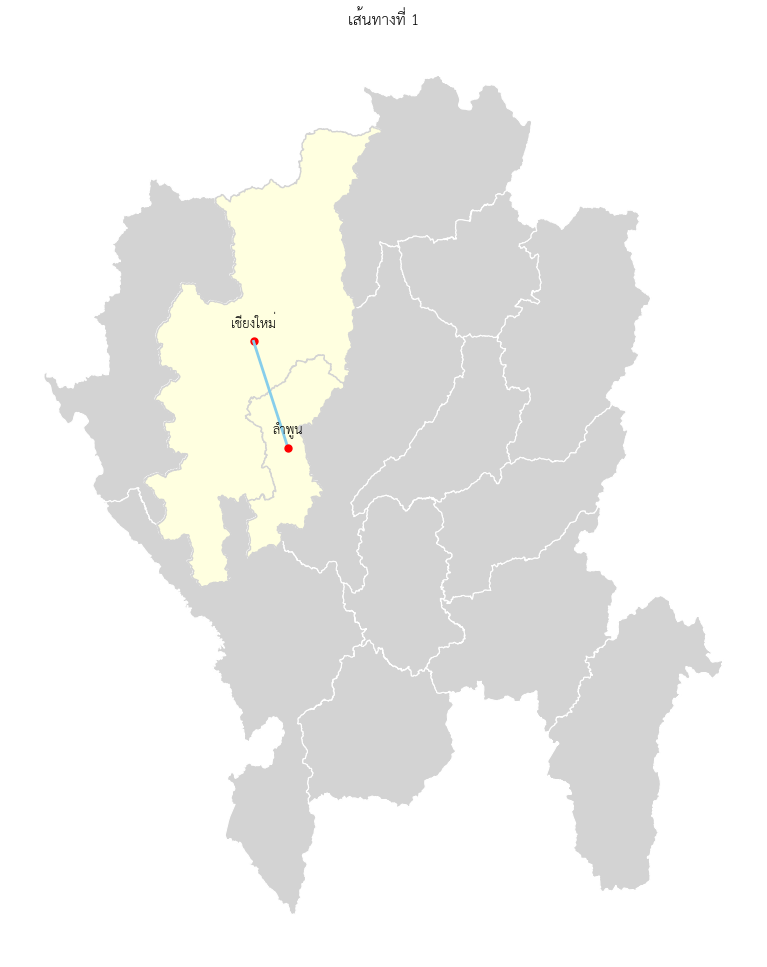

เส้นทางที่ 2: เชียงใหม่ > ลำปาง > ลำพูน (ระยะทางรวม: 306 km)


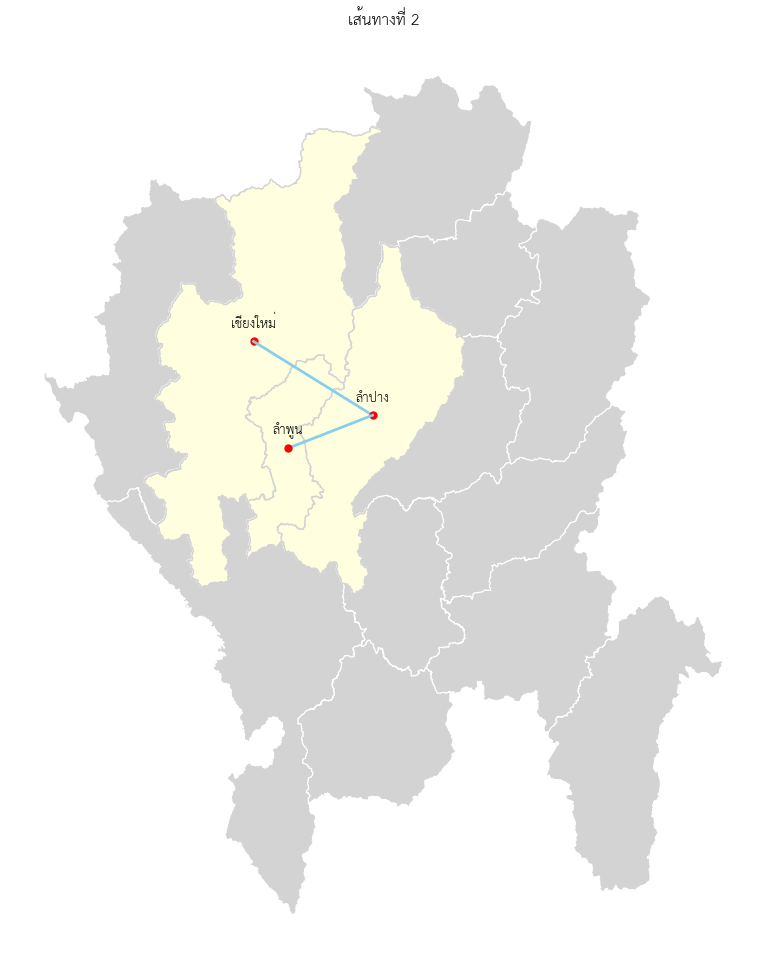

เส้นทางที่ 3: เชียงใหม่ > เชียงราย > ลำปาง > ลำพูน (ระยะทางรวม: 501 km)


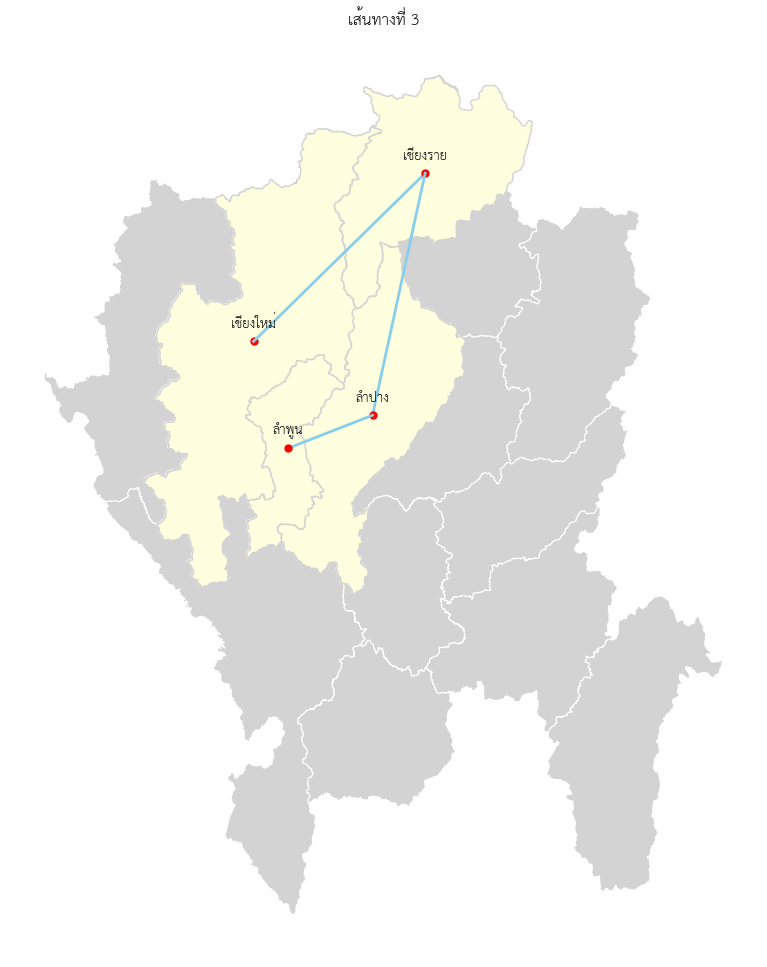

เส้นทางที่ 4: เชียงใหม่ > เชียงราย > พะเยา > ลำปาง > ลำพูน (ระยะทางรวม: 517 km)


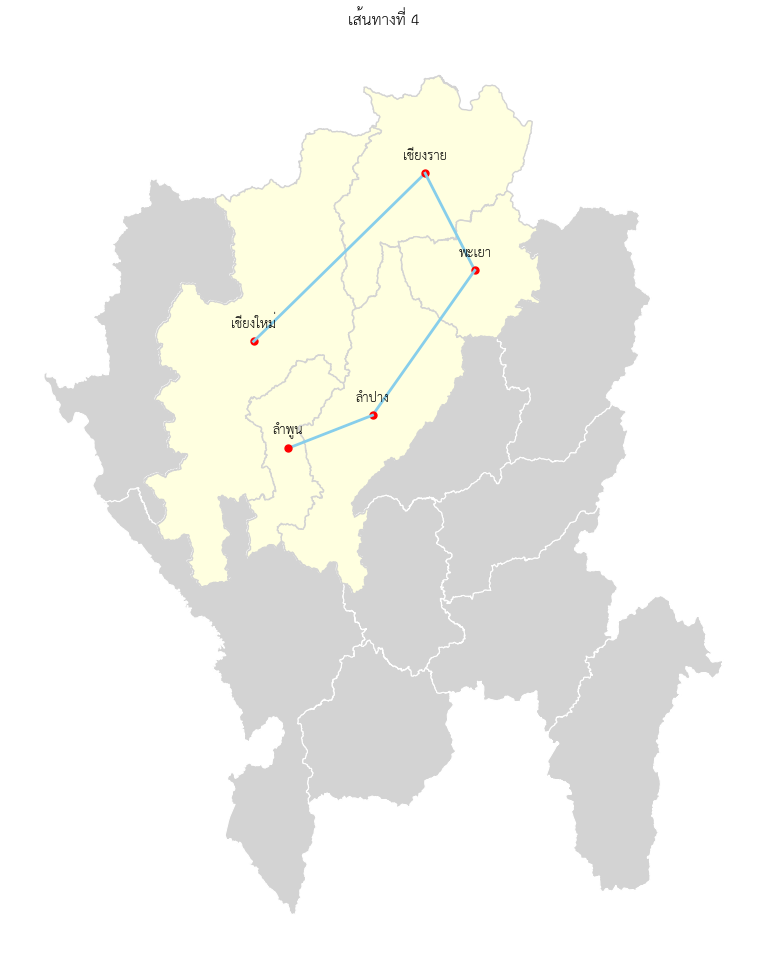

เส้นทางที่ 5: เชียงใหม่ > เชียงราย > พะเยา > น่าน > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 907 km)


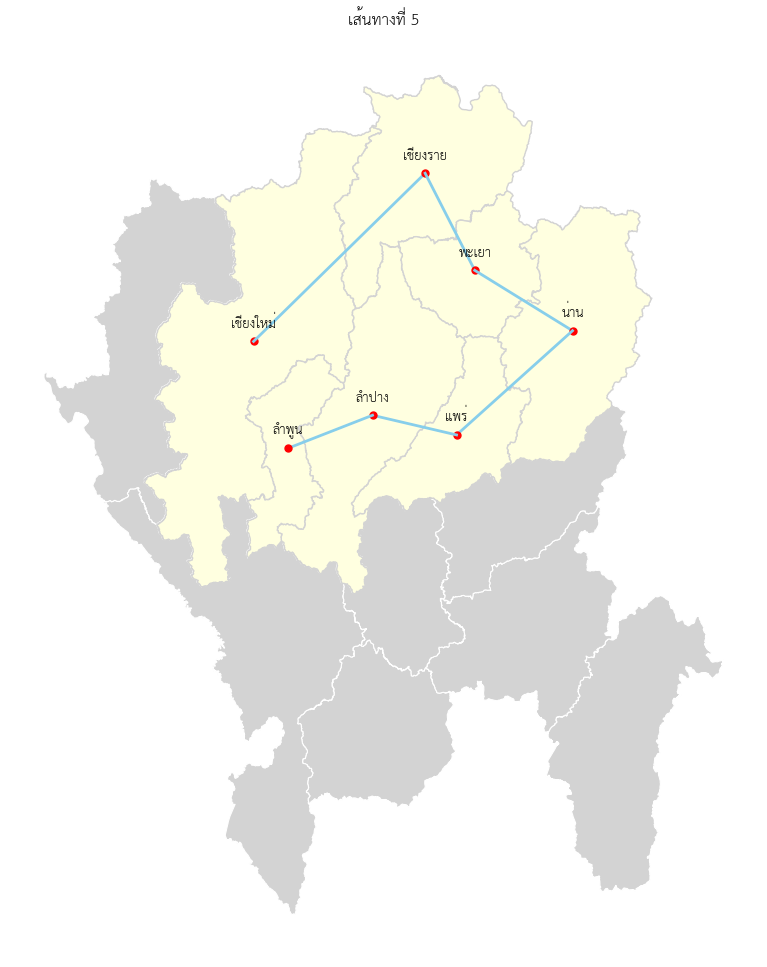

เส้นทางที่ 6: เชียงใหม่ > เชียงราย > พะเยา > น่าน > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 907 km)


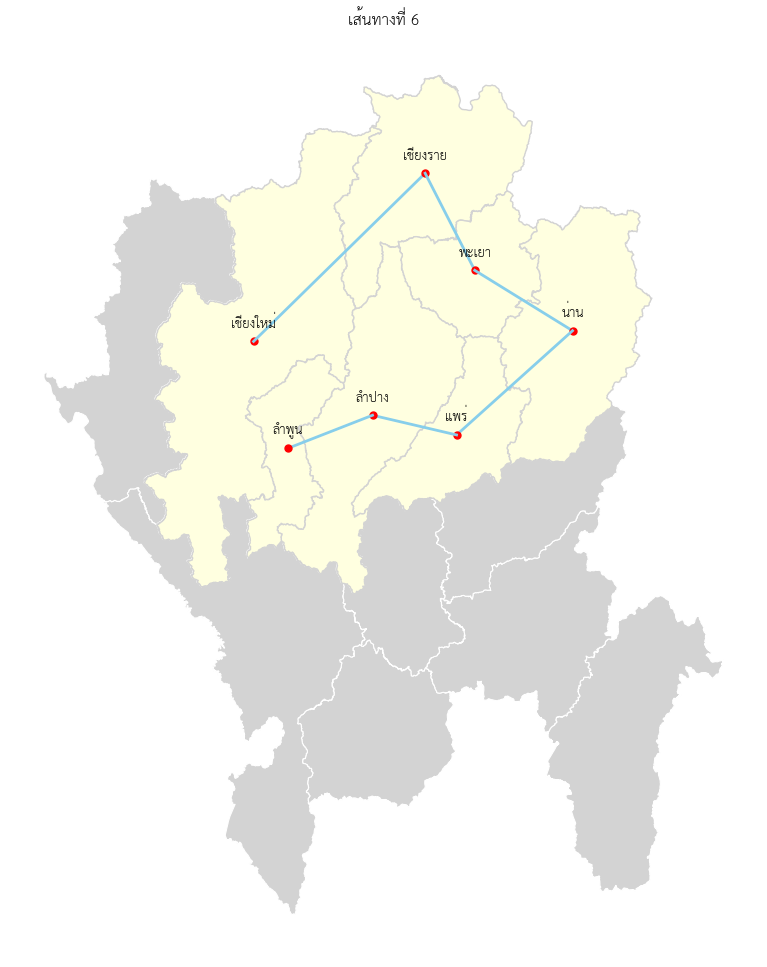

เส้นทางที่ 7: เชียงใหม่ > เชียงราย > พะเยา > น่าน > อุตรดิตถ์ > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 1080 km)


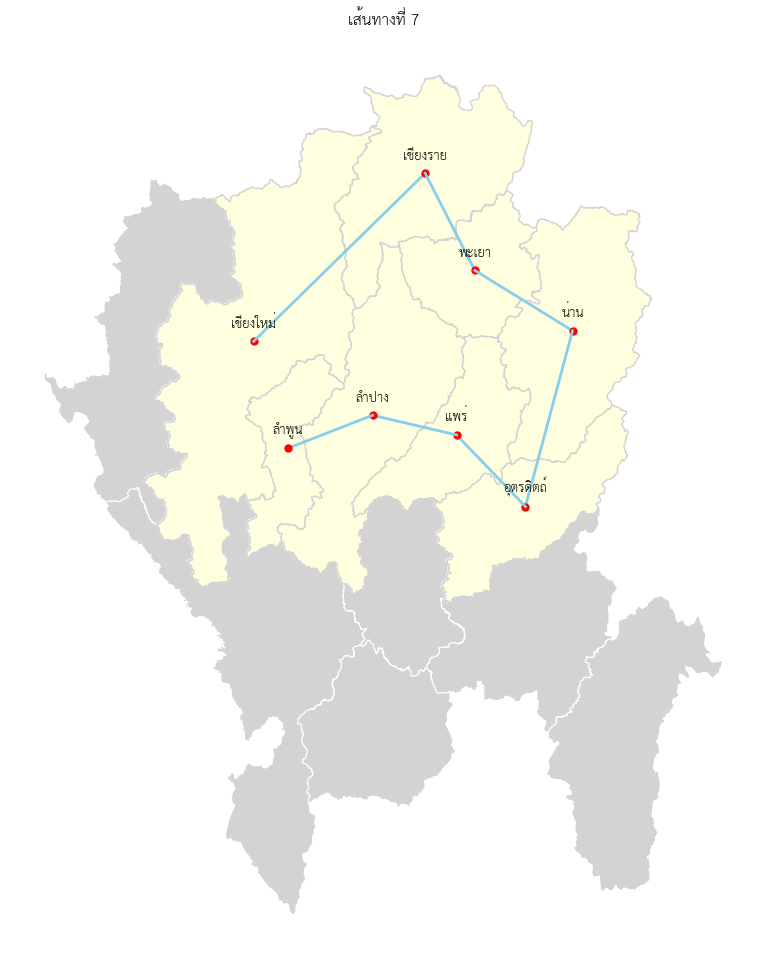

เส้นทางที่ 8: เชียงใหม่ > เชียงราย > พะเยา > น่าน > อุตรดิตถ์ > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 1080 km)


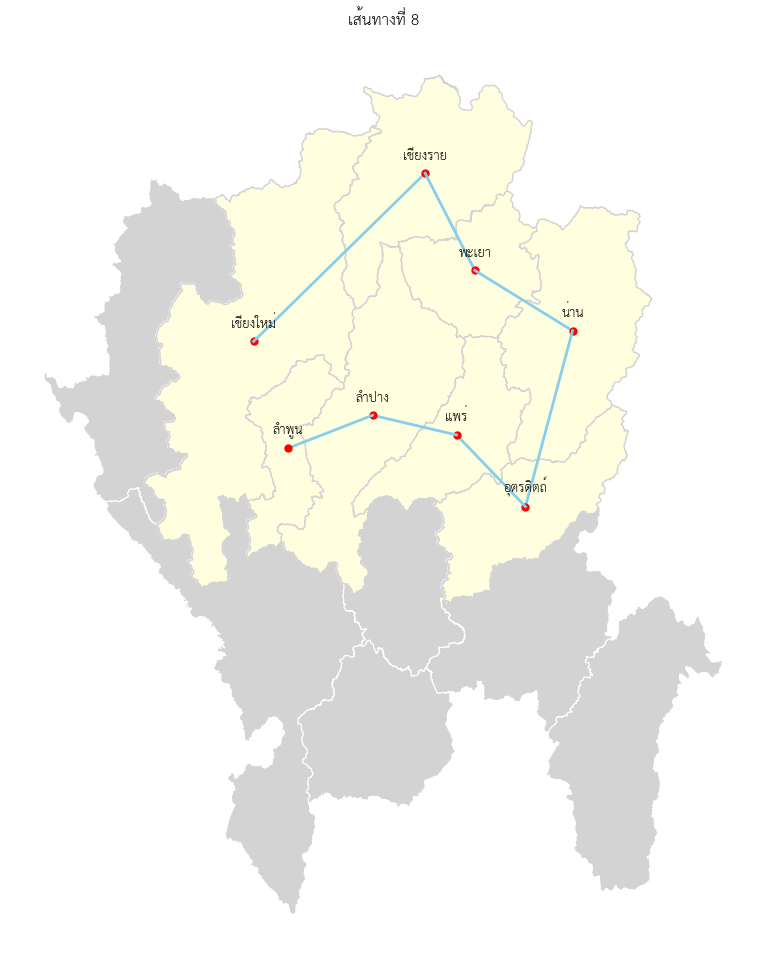

เส้นทางที่ 9: เชียงใหม่ > แม่ฮ่องสอน > ตาก > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1144 km)


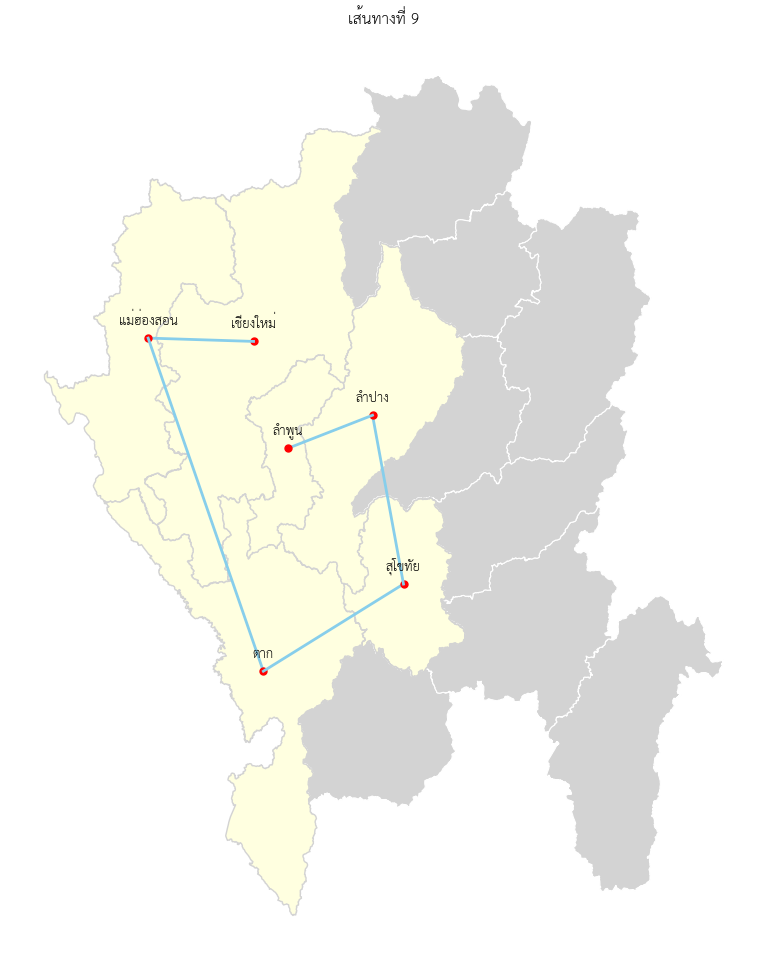

เส้นทางที่ 10: เชียงใหม่ > เชียงราย > พะเยา > น่าน > อุตรดิตถ์ > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1171 km)


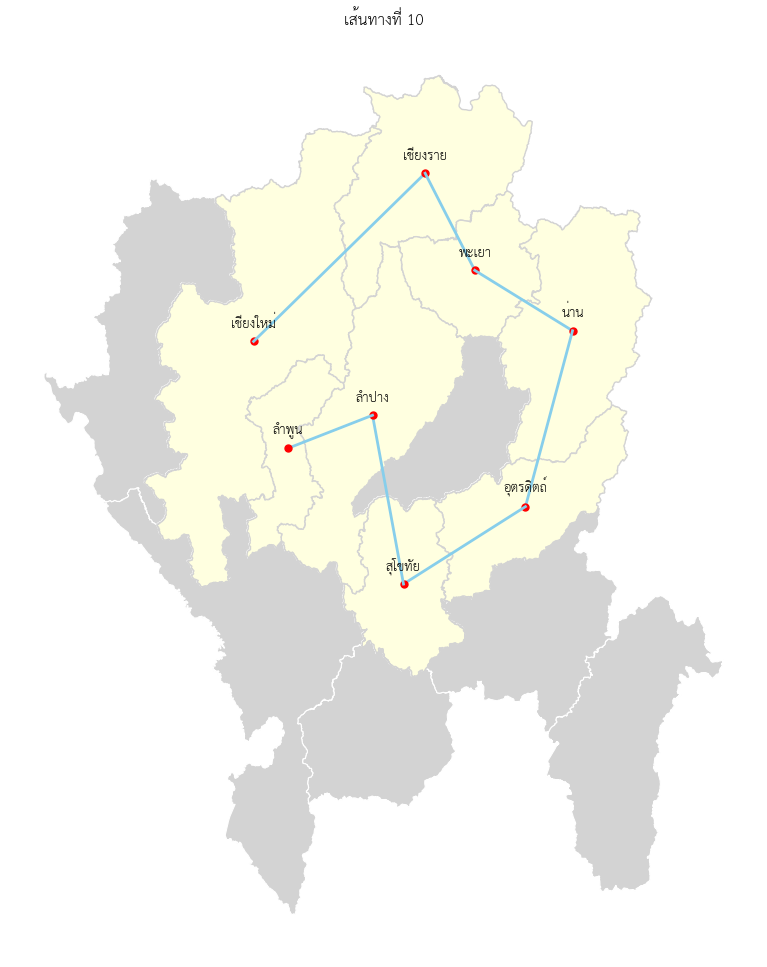

เส้นทางที่ 11: เชียงใหม่ > แม่ฮ่องสอน > ตาก > สุโขทัย > อุตรดิตถ์ > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 1213 km)


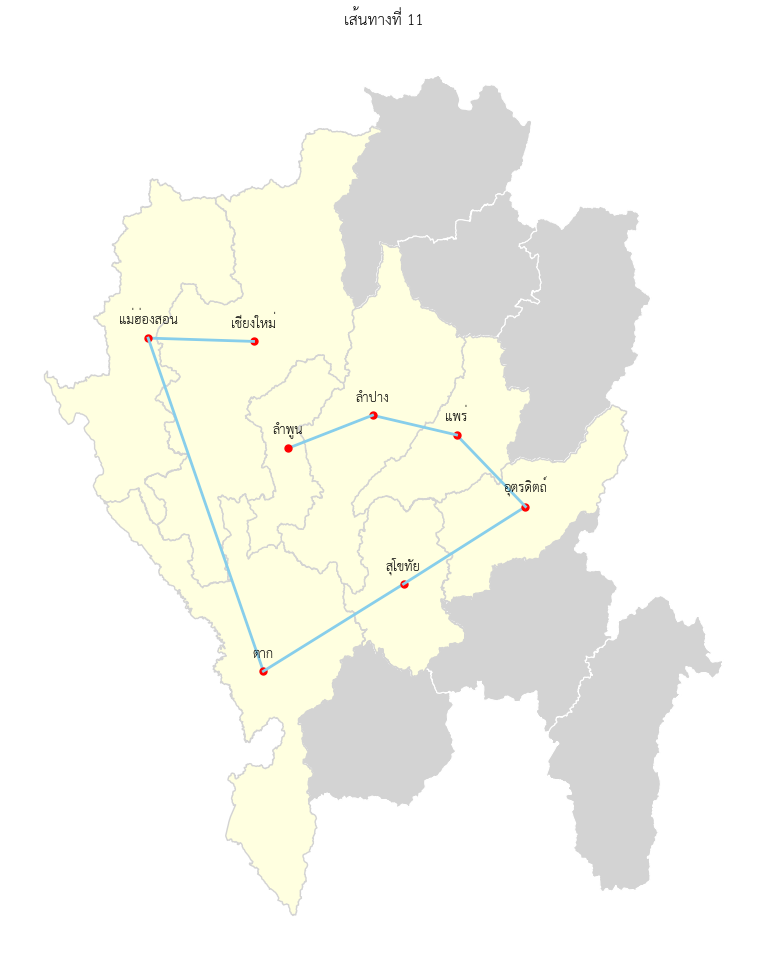

เส้นทางที่ 12: เชียงใหม่ > แม่ฮ่องสอน > ตาก > สุโขทัย > อุตรดิตถ์ > แพร่ > ลำปาง > ลำพูน (ระยะทางรวม: 1213 km)


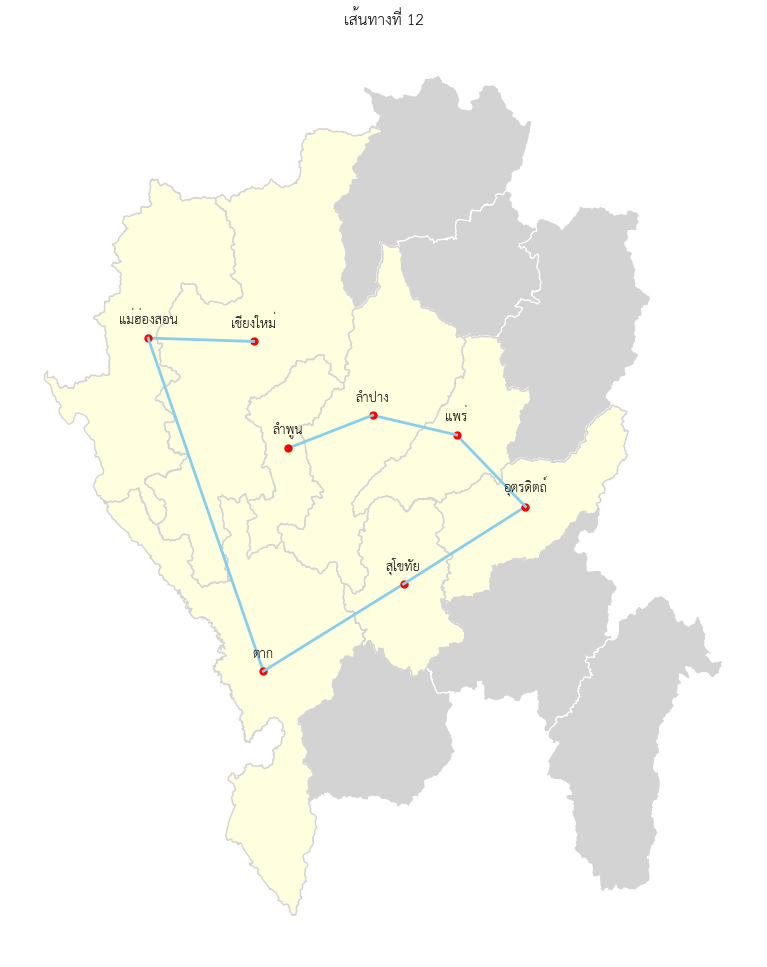

เส้นทางที่ 13: เชียงใหม่ > แม่ฮ่องสอน > ตาก > กำแพงเพชร > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1353 km)


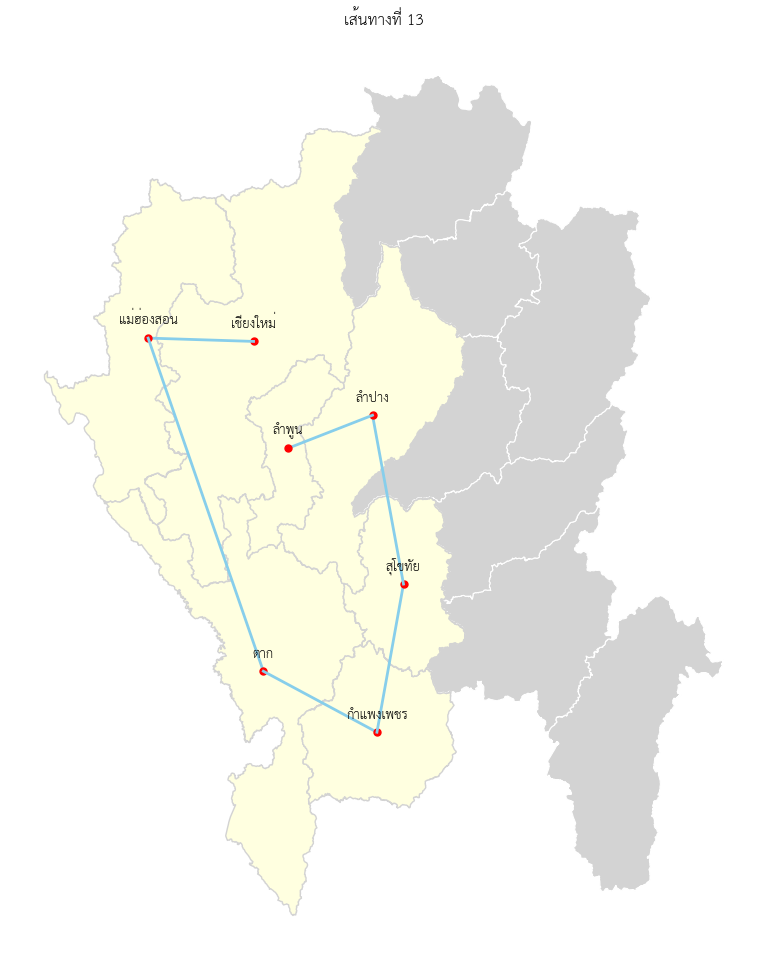

เส้นทางที่ 14: เชียงใหม่ > แม่ฮ่องสอน > ตาก > กำแพงเพชร > สุโขทัย > ลำปาง > ลำพูน (ระยะทางรวม: 1361 km)


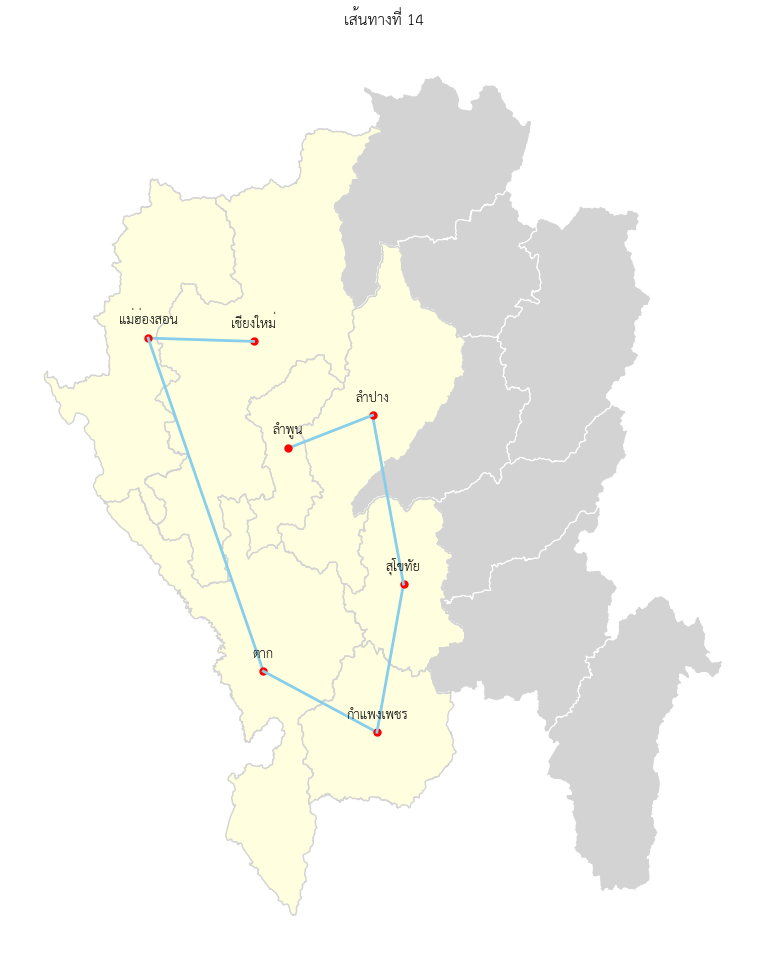

In [14]:
# สร้างแผนที่ของเส้นทางแต่ละเส้นทางที่จะท่องเที่ยว
# ไม่ใช่เส้นทางจริง เพียงแต่เป็นการแสดงความเชื่อมโยงของเส้นทาง

# ระยะทางกำกับเส้นทาง
distance_label = False

# เลือกภาค northern_thailand, all_thailand
selected_area = northern_thailand

# size
figs=12

if results:
    mpl.rcParams['font.size'] = 14
    print("เริ่มเดินทางจากจังหวัด: " + start_location + \
          "\nจำนวนวันสูงสุด: " + str(int(max_day)) + \
          "\nจำนวนระยะทางสูงสุด(km): " + str(max_distance) + "\n")

    for i, (path, total_distance) in enumerate(results, 1):
        print(f"เส้นทางที่ {i}: {' > '.join(path)} (ระยะทางรวม: {total_distance} km)")

        # สร้างแผนที่ใหม่สำหรับแต่ละเส้นทาง
        fig, ax = plt.subplots(1, 1, figsize=(figs, figs))

        # แปลงข้อมูลเป็น EPSG:32647 (UTM Zone 47N)
        selected_area = selected_area.to_crs(epsg=32647)

        # พล็อตจังหวัดทั้งหมดเป็นสีเทา
        selected_area.plot(color='lightgray', edgecolor='white', linewidth=0.8, ax=ax)

        ax.set_title(f'เส้นทางที่ {i}')
        ax.set_axis_off()  # ปิดกรอบแสดงผล

        # พล็อตจุดและเส้นทาง
        for j in range(len(path)):
            province = path[j]
            province_data = selected_area[selected_area['ADM1_TH'] == province]
            if not province_data.empty:
                # หาจุดกึ่งกลางของจังหวัด
                centroid = province_data.geometry.centroid.iloc[0]

                # Highlight จังหวัดที่อยู่ในเส้นทาง (สีเหลือง)
                province_data.plot(color='lightyellow', edgecolor='lightgray', ax=ax)

                # พล็อตจุด (สีแดง)
                ax.plot(centroid.x, centroid.y, marker='o', color='red', markersize=5)
                ax.annotate(province, (centroid.x, centroid.y), textcoords="offset points", xytext=(0, 10), ha='center')

                if j < len(path) - 1:
                    next_province = path[j + 1]
                    next_province_data = selected_area[selected_area['ADM1_TH'] == next_province]
                    if not next_province_data.empty:
                        next_centroid = next_province_data.geometry.centroid.iloc[0]

                        # หาระยะทางที่แท้จริงจาก locations
                        actual_distance = next((entry['distance'] for entry in locations if entry['ptp'] == {province, next_province}), None)
                        if actual_distance is not None:
                            # พล็อตเส้นทาง (สีน้ำเงิน)
                            ax.plot([centroid.x, next_centroid.x], [centroid.y, next_centroid.y], color='skyblue', linewidth=2)

                        # ระยะทางกำกับเส้นทาง
                        if distance_label:
                            # เพิ่มระยะทางบนเส้นทาง
                            mid_x = (centroid.x + next_centroid.x) / 2
                            mid_y = (centroid.y + next_centroid.y) / 2
                            ax.annotate(f"{actual_distance}", (mid_x, mid_y), textcoords="offset points",
                                        xytext=(5, 5), ha='center', fontsize=14, color='black')

        # แสดงแผนที่พร้อมเส้นทาง
        plt.show()
else:
    print("ไม่มีเส้นทางที่เหมาะสม")